In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

from diffpy.mpdf import *
import maginteractions

from diffpy.structure import loadStructure
from diffpy.structure import structure
from diffpy.structure import lattice
from diffpy.structure import atom

%matplotlib notebook

In [2]:
# Build unit cell

a = 6.20746/2
base = np.array([[0, a, a],
                 [a, 0, a],
                 [a, a, 0]])
lat = lattice.Lattice(base = base)

Mn = atom.Atom(atype = 'Mn', label = 'Mn', occupancy = 0.5)
Zn = atom.Atom(atype = 'Zn', label = 'Zn', occupancy = 0.5)
Te = atom.Atom(atype = 'Te', xyz = [1/2, 1/2, 1/2], label = 'Zn', occupancy = 1.0)

struc = structure.Structure(atoms = [Mn, Zn, Te], title = 'ZnMn',lattice = lat)

In [3]:
struc0 = loadStructure('ZnMnTeData/ZnMnTe_4K_fit.stru')
lat0 = struc0.lattice

bvecs = np.array([[0, 1, 0],
                  [0, -1, 0]])
kvecs = np.array([[0, 0.5, 0]])
occ = 0.5
idx = 4
ms1 = MagSpecies(struc0, strucIdxs = [4], basisvecs = bvecs[0], kvecs = kvecs,
                 ffparamkey = 'Mn2', origin = lat0.cartesian(struc0[4].xyz), occ = occ)
ms2 = MagSpecies(struc0, strucIdxs = [6], basisvecs = bvecs[1], kvecs = kvecs,
                 ffparamkey = 'Mn2', origin = lat0.cartesian(struc0[4].xyz), occ = occ)
ms3 = MagSpecies(struc0, strucIdxs = [5], basisvecs = bvecs[0], kvecs = kvecs,
                 ffparamkey = 'Mn2', origin = lat0.cartesian(struc0[5].xyz), occ = occ)
ms4 = MagSpecies(struc0, strucIdxs = [7], basisvecs = bvecs[1], kvecs = kvecs,
                 ffparamkey = 'Mn2', origin = lat0.cartesian(struc0[5].xyz), occ = occ)

mstruc0 = MagStructure()
mstruc0.loadSpecies(ms1)
mstruc0.loadSpecies(ms2)
mstruc0.loadSpecies(ms3)
mstruc0.loadSpecies(ms4)
mstruc0.makeAll()

<IPython.core.display.Javascript object>


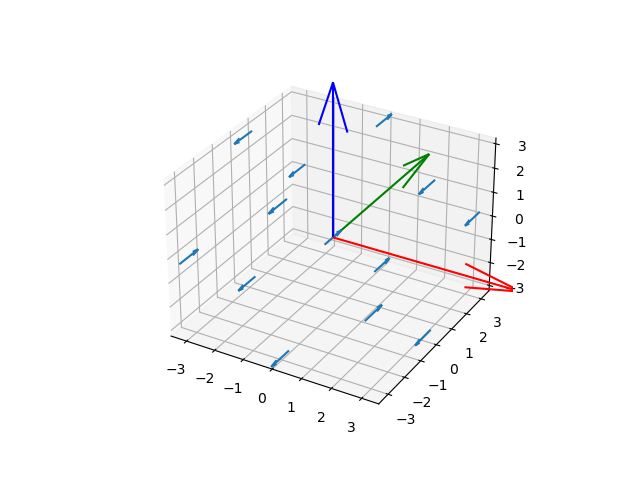

In [4]:
distances = np.apply_along_axis(np.linalg.norm, 1, mstruc0.atoms)
viewmask = distances < 6
mstruc0.visualize(mstruc0.atoms[viewmask], mstruc0.spins[viewmask], showcrystalaxes=True)

In [5]:
magstruc = MagStructure()

mspec = MagSpecies()
mspec.struc = struc
mspec.strucIdxs = [0]
mspec.setOcc()
mspec.basisvecs = np.array([0,1,0]) @ lat.baserot
mspec.label = 'Mn2'
mspec.ffparamkey = 'Mn2'

magstruc.loadSpecies(mspec)
magstruc.makeAll()
magstruc.spins = mstruc0.spins
magstruc.atoms = mstruc0.atoms
magstruc.calcIdxs = mstruc0.calcIdxs

In [6]:
### import data

high_idx = 2 # index where paramagnet data starts

[data_temps, xi_data, xi_err] = np.loadtxt('ZnMnTeData/finalfitsdmag_convolvedwindowfunc_normalizeddata_xivals.txt',
                                           delimiter=' ').T
[data_temps_high, xi_high_data, xi_high_err] = np.loadtxt('ZnMnTeData/finalfitsdmag_convolvedwindowfunc_normalizeddata_xivals.txt',
                                                          delimiter=' ')[high_idx:].T

[_, lmop_data, lmop_err] = np.loadtxt('ZnMnTeData/finalfitsdmag_convolvedwindowfunc_normalizeddata_mvals.txt',
                                      skiprows=1,delimiter=' ').T
[_, lmop_high_data, lmop_high_err] = np.loadtxt('ZnMnTeData/finalfitsdmag_convolvedwindowfunc_normalizeddata_mvals.txt',
                                                skiprows=1,delimiter=' ')[high_idx:].T

# Previously published values

In [8]:
temps = np.linspace(0.1,300.0,100)

In [9]:
# Calculate J(q)

r_max = 8.0 # maximum exchange distance
spin_squared = 0.5 * 35 / 4 # 0.5 * 2.18 * 3.18 # spin length squared

j_ij_87 = [-9.5, -1.9] # (Furdyna & Samarth 1987)
magint_87 = maginteractions.MagInteractions(magstruc = magstruc, temperatures = temps, j_ij = j_ij_87,
                                            spin_squared = spin_squared, r_max = r_max)
magint_87.make_interaction_matrix()
magint_87.calculate_orf_reciprocal_space(n_bz_vecs = 6) # populates J(q) in reciprocal space, calculates ORF

orfs_reciprocal_space = magint_87.orfs.copy()

/home/edison/Documents/Projects/MagInteractions/maginteractions.py:225: ComplexWarning: Casting complex values to real discards the imaginary part
  u_q[k] = eig_vecs.astype('float64')


<IPython.core.display.Javascript object>


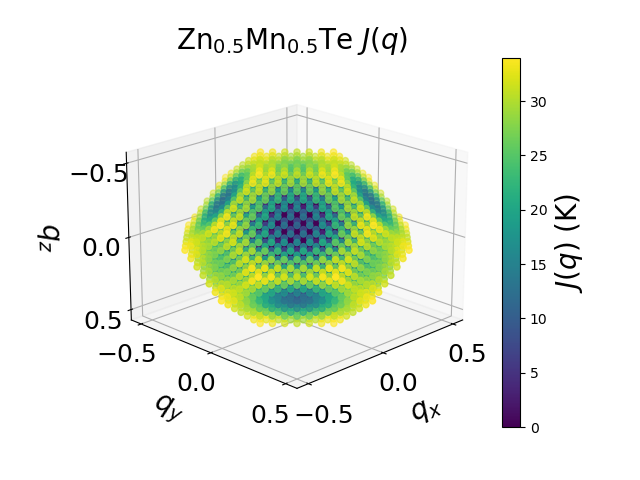

In [10]:
# visualize J(q)

import matplotlib.colors as mcolors

qxs, qys, qzs = magint_87.q_vecs.T

vmin = 0
vmax = 34

qa = 2.02161689

fontsize = 20
ticksize = 18
labelpad = 12

fig, ax = plt.subplots(subplot_kw = {"projection": "3d"})
norm = mcolors.Normalize(vmin = vmin, vmax = vmax)
j_q_plot = ax.scatter(a / (2 * np.pi) * qxs, a / (2 * np.pi) * qys, a / (2 * np.pi) * qzs,
                      c = magint_87.j_q[:,-1], norm = norm)
ax.set_xlabel(r'$q_x$', fontsize = fontsize, labelpad = labelpad)
ax.set_ylabel(r'$q_y$', fontsize = fontsize, labelpad = labelpad)
ax.set_zlabel(r'$q_z$', fontsize = fontsize, labelpad = labelpad)
cbar = fig.colorbar(j_q_plot)
cbar.set_label(r'$J(q)$ (K)', fontsize = fontsize)
ax.set_title(r'Zn$_{0.5}$Mn$_{0.5}$Te $J(q)$', fontsize = fontsize)
ax.view_init(elev = -160, azim = -45)
ax.tick_params(axis = 'x', labelsize = ticksize)
ax.tick_params(axis = 'y', labelsize = ticksize)
ax.tick_params(axis = 'z', labelsize = ticksize)

plt.savefig('figures/ZnMnTeJq.png', dpi = 600)
plt.show()

<IPython.core.display.Javascript object>


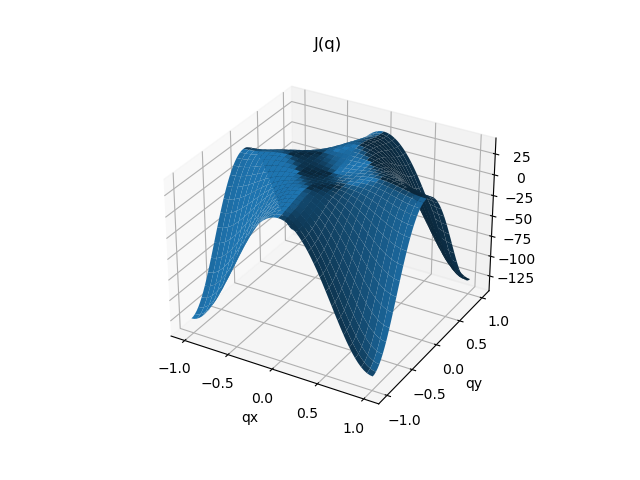

In [11]:
# visualize J(q) at qz=0

qa = 2 * np.pi / a

qx = np.linspace(-qa / 2, qa / 2, 65)
qy = np.linspace(-qa / 2, qa / 2, 65)
qx, qy = np.meshgrid(qx, qy)
qz = 0.5 * qa


j_qs = np.zeros((magint_87.N, 1) + qx.shape)
u_qs = np.zeros((magint_87.N, magint_87.N, 1) + qx.shape)
for i in range(qx.shape[0]):
    for j in range(qx.shape[1]):
        j_qs[:,:,i,j], u_qs[:,:,:,i,j] = magint_87.calc_j_q([qx[i,j], qy[i,j], qz],
                                                          return_eig_vecs = True)
        
j_qs =j_qs.reshape((magint_87.N,) + qx.shape)
u_qs = u_qs.reshape((magint_87.N, magint_87.N,) + qx.shape)

tidx = 5

for k in range(magint_87.N):
    fig, ax = plt.subplots(subplot_kw = {"projection": "3d"})
    ax.plot_surface(qx, qy, j_qs[k])
    ax.set_zlim(-140, 40)
    ax.set_title('J(q)')
    ax.set_xlabel('qx')
    ax.set_ylabel('qy')
    plt.show()

In [12]:
# where is the maximum Jq?

print(f'Jq = {np.max(j_qs)}')
idx = np.unravel_index(np.argmax(j_qs, axis = None), j_qs.shape)
qmax = np.array([qx[idx[1:]], qy[idx[1:]], qz])
print(f'q = {qmax}')
print(f'q = {qmax @ np.linalg.inv(magint_87.recip_lats)} (rlu)')
print(f'q = {qmax * 2 / qa} (units of 2pi/a)')

Jq = 34.2
q = [ 0.         -0.50609954  1.01219908]
q = [ 0.25  0.5  -0.25] (rlu)
q = [ 0.  -0.5  1. ] (units of 2pi/a)


In [13]:
# Calculate Correlation Parameters

import time
start = time.perf_counter()

ord_vec = qa / 2 * np.array([1, 1/2, 0])
n_ord_vec = 6

magint_87.calculate_correlation_parameters(ord_vec = ord_vec, n_ord_vec = n_ord_vec, calc_orf = True,
                                           sum_rule_orf = False, n_bz_vecs = 6, isotropic = True)

lmop_87 = magint_87.lmops
xis_87 = np.nan_to_num(np.linalg.eigvals(magint_87.damping_matrices)**(-1/2), nan=50)

xis_87_avg_geo = np.exp(np.mean(np.log(xis_87), axis = 1))

end = time.perf_counter()
print(f"Elapsed time: {end - start} seconds")

Elapsed time: 3.1883032489986363 seconds


<IPython.core.display.Javascript object>


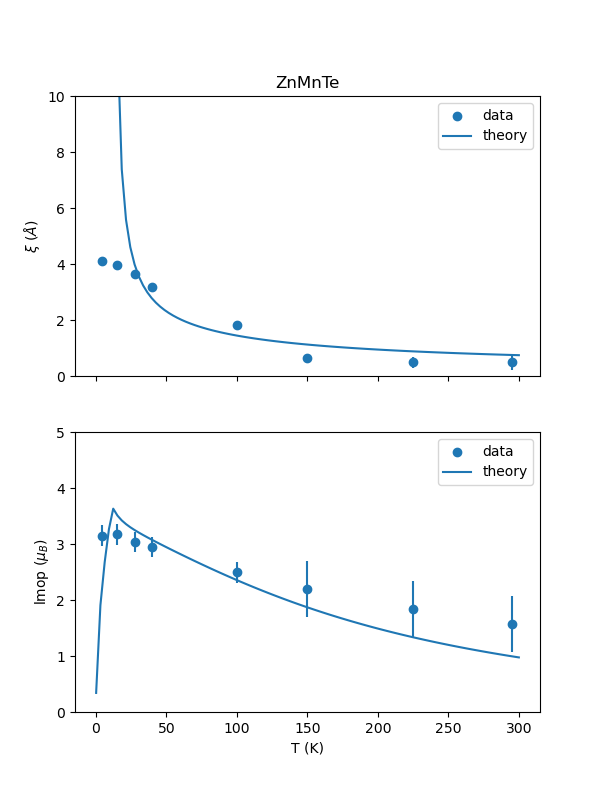

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (6, 8))

ax1.set_title('ZnMnTe')
ax1.scatter(data_temps, xi_data, label = 'data')
ax1.errorbar(data_temps, xi_data, yerr = xi_err, fmt = 'none')
ax1.plot(temps, xis_87_avg_geo, label = 'theory')
ax1.set_ylim(0, 10)
ax1.set_ylabel(r'$\xi$ ($\AA$)')
ax1.legend()

ax2.scatter(data_temps, lmop_data, label = 'data')
ax2.errorbar(data_temps, lmop_data, yerr = lmop_err, fmt = 'none')
ax2.plot(temps, lmop_87, label = 'theory')
ax2.set_ylim(0, 5)
ax2.set_xlabel('T (K)')
ax2.set_ylabel(r'lmop ($\mu_B$)')
ax2.legend()

plt.show()

<IPython.core.display.Javascript object>


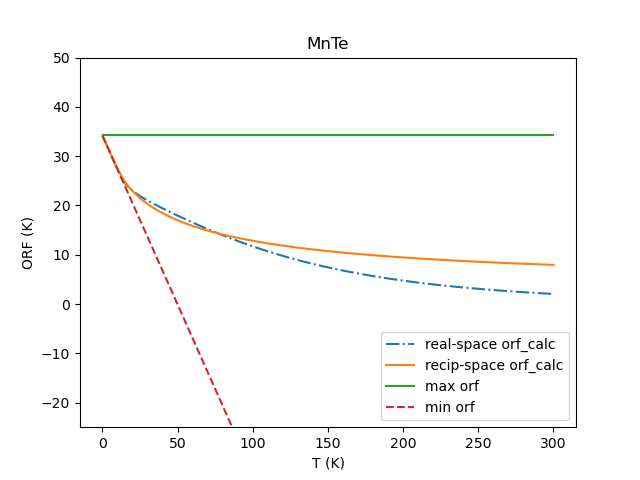

In [15]:
# Visualize ORF

fig, ax = plt.subplots()
ax.plot(temps, magint_87.orfs, '-.', label = 'real-space orf_calc')
ax.plot(temps, orfs_reciprocal_space, label = 'recip-space orf_calc')
ax.plot(temps, np.max(magint_87.j_q) * np.ones_like(temps), label = 'max orf')
ax.plot(temps, np.max(magint_87.j_q) - 3 * temps / spin_squared, '--', label = 'min orf')
ax.legend()
ax.set_ylim(-25, 50)
ax.set_xlabel('T (K)')
ax.set_ylabel('ORF (K)')
ax.set_title('MnTe')
plt.show()

<IPython.core.display.Javascript object>


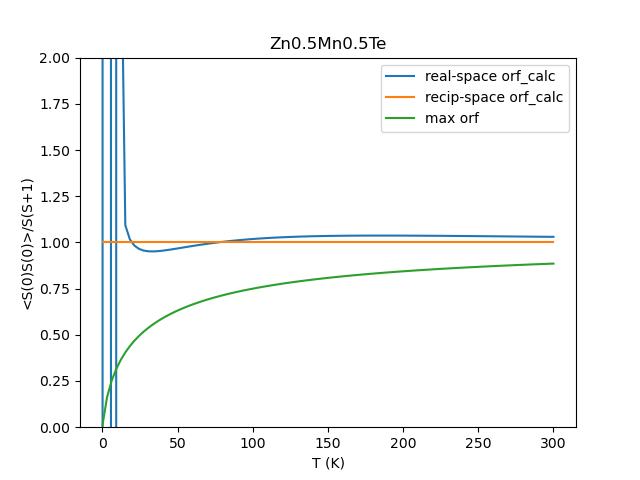

In [15]:
chi0 = spin_squared / 3 / temps
orf_sum_real = np.array([np.sum((1 - chi0[i] * (magint_87.j_q - magint_87.orfs[i]))**(-1))
                         for i in range(len(temps))])
orf_sum_recip = np.array([np.sum((1 - chi0[i] * (magint_87.j_q - orfs_reciprocal_space[i]))**(-1))
                          for i in range(len(temps))])
orf_sum_max = np.array([np.sum((1 - chi0[i] * (magint_87.j_q - np.max(magint_87.j_q)))**(-1))
                        for i in range(len(temps))])

fig, ax = plt.subplots()
ax.plot(temps, orf_sum_real / (magint_87.N * len(magint_87.q_vecs)), label = 'real-space orf_calc')
ax.plot(temps, orf_sum_recip / (magint_87.N * len(magint_87.q_vecs)), label = 'recip-space orf_calc')
ax.plot(temps, orf_sum_max / (magint_87.N * len(magint_87.q_vecs)), label = 'max orf')
ax.set_xlabel('T (K)')
ax.set_ylabel('<S(0)S(0)>/S(S+1)')
ax.set_title('Zn0.5Mn0.5Te')
ax.legend()
ax.set_ylim(0, 2)
plt.show()

# Fit from previously published values

In [17]:
rmax = 8.0 # maximum exchange distance
# spin_squared = 0.5 * 35 / 4 # spin length squared
n_ord_vec = 6
qa = 2 * np.pi / a
ordVec = qa / 2 * np.array([1, 1/2, 0])
sum_rule_orf = False
method = 'dogbox'

def model(x, theta):
    magint = maginteractions.MagInteractions(magstruc = magstruc, temperatures = x, j_ij = theta,
                                             spin_squared = spin_squared, r_max = r_max)
    magint.make_interaction_matrix()
    magint.calculate_correlation_parameters(ord_vec = ord_vec, n_ord_vec = n_ord_vec, calc_orf = True,
                                            sum_rule_orf = sum_rule_orf, n_bz_vecs = 6, isotropic = True)

    
    lmops = magint.lmops   
    xis = np.nan_to_num(np.linalg.eigvals(magint.damping_matrices), 50)**(-1/2)
    xis = np.exp(np.mean(np.log(xis), axis = 1))
    
    return np.concatenate([xis, lmops])
    
def residuals(theta):
    f = model(data_temps_high, theta)
    
    res = f - np.concatenate([xi_high_data, lmop_high_data])
    weights = 1/np.concatenate([xi_high_err, lmop_high_err])
    return res * weights

bounds = ([-np.inf, -np.inf], [0, 0])
theta = [-9.5, -1.9] # J. Appl. Phys. 61, 3526–3531 (1987)
result = least_squares(residuals, theta, method=method, bounds=bounds)

In [18]:
j_ij_fit = result.x

magint_fit = maginteractions.MagInteractions(magstruc = magstruc, temperatures = temps,
                                             j_ij = j_ij_fit, spin_squared = spin_squared, r_max = r_max)
magint_fit.make_interaction_matrix()
magint_fit.calculate_correlation_parameters(ord_vec = ord_vec, n_ord_vec = n_ord_vec, calc_orf = True,
                                            sum_rule_orf = sum_rule_orf, n_bz_vecs = 6, isotropic = True)

lmop_fit = magint_fit.lmops
xis_fit = np.nan_to_num(np.linalg.eigvals(magint_fit.damping_matrices), nan=50)**(-1/2)
xis_fit_avg_geo = np.exp(np.mean(np.log(xis_fit), axis = 1))

<IPython.core.display.Javascript object>


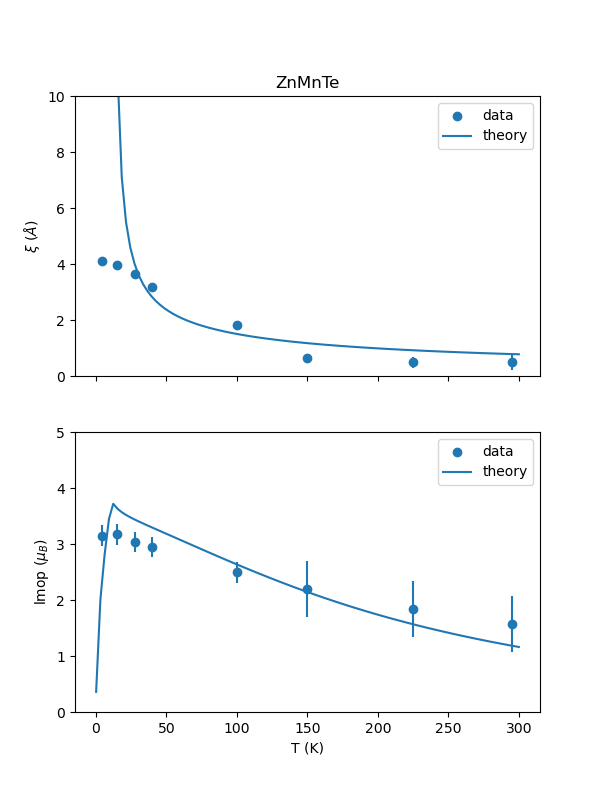

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (6, 8))

ax1.set_title('ZnMnTe')
ax1.scatter(data_temps, xi_data, label = 'data')
ax1.errorbar(data_temps, xi_data, yerr = xi_err, fmt = 'none')
ax1.plot(temps, xis_fit_avg_geo, label = 'theory')
ax1.set_ylim(0, 10)
ax1.set_ylabel(r'$\xi$ ($\AA$)')
ax1.legend()

ax2.scatter(data_temps, lmop_data, label = 'data')
ax2.errorbar(data_temps, lmop_data, yerr = lmop_err, fmt = 'none')
ax2.plot(temps, lmop_fit, label = 'theory')
ax2.set_ylim(0, 5)
ax2.set_xlabel('T (K)')
ax2.set_ylabel(r'lmop ($\mu_B$)')
ax2.legend()

plt.show()

In [20]:
print(f'J1, J2 = {result.x}')

J1, J2 = [-10.4821606   -1.03938799]


In [21]:
print(f'FIM = {result.jac.T@result.jac}')
print(f'Conditional Variance = {np.diag(result.jac.T@result.jac)**(-1/2)}')
print(f'Variance = {np.diag(np.linalg.inv(result.jac.T@result.jac))**(1/2)}')

FIM = [[  13.86461175 -212.92249691]
 [-212.92249691 3520.27916203]]
Conditional Variance = [0.26856298 0.01685433]
Variance = [1.00702811 0.06319852]


In [22]:
vals, vecs = np.linalg.eig(result.jac.T@result.jac)
for i in range(len(vals)):
    print(vals[i]**(-1/2))
    print(vecs[:,i])

1.0088689874315344
[-0.9981748  -0.06039101]
0.01682357423765753
[ 0.06039101 -0.9981748 ]


In [23]:
rdat, mpdfobs, mpdfcalc = np.loadtxt('ZnMnTeData/finalfitsdmag_convolvedwindowfunc_normalizeddata_28K.txt',skiprows=1,delimiter=' ').T

In [24]:
# Calculate mPDF

# 28K: tidx = 9
# 40K: tidx = 13
# 100K: tidx = 33

mPDF_tidx = 9

qmin = 0 # 0.36248625
qmax = 5
windowedgewidth = 1.5

mstruc = magstruc.copy()
mstruc.ffqgrid = np.linspace(qmin, qmax, 150)
mstruc.ff = jCalc(mstruc.ffqgrid, getFFparams('Mn2'))

mstruc.dampingMat = magint_fit.damping_matrices[mPDF_tidx]
mc = MPDFcalculator(mstruc)
mc.qdamp = 0.025
mc.qmin = qmin
mc.qmax = qmax
mc.rmax = 30
mc.qgrid = mstruc.ffqgrid
mc.qwindow = window_FD(mc.qgrid, qmax, windowedgewidth)

mc.ordScale = magutils.calculate_ordered_scale(mstruc, magint_fit.lmops[mPDF_tidx])
mc.paraScale = 0.585845 * mc.ordScale

mc.ordScale *= np.exp(magint_fit.r_nn / xis_fit_avg_geo[mPDF_tidx])

sublattice1 = np.all(mstruc.spins == mstruc.spins[0], axis = 1) # select all spins that are identical to the first spin
sublattice2 = ~sublattice1 # select all other spins

theta = 1.87834649
phi = -2.33769161
sx = np.sin(theta) * np.cos(phi) # x, y, and z components of the spin
sy = np.sin(theta) * np.sin(phi)
sz = np.cos(theta)
spin_vec = np.array([sx, sy, sz])
mstruc.spins[sublattice1] = spin_vec
mstruc.spins[sublattice2] = -spin_vec

rcalc, dcalc = mc.calc(correlationMethod='full', normalized = False, both = False)

/home/edison/anaconda3/envs/diffpy/lib/python3.7/site-packages/diffpy/mpdf/magstructure.py:987: RuntimeWarning: invalid value encountered in true_divide
  distanceVecsN = distanceVecs/np.apply_along_axis(np.linalg.norm,1,distanceVecs)[:,np.newaxis]


<IPython.core.display.Javascript object>


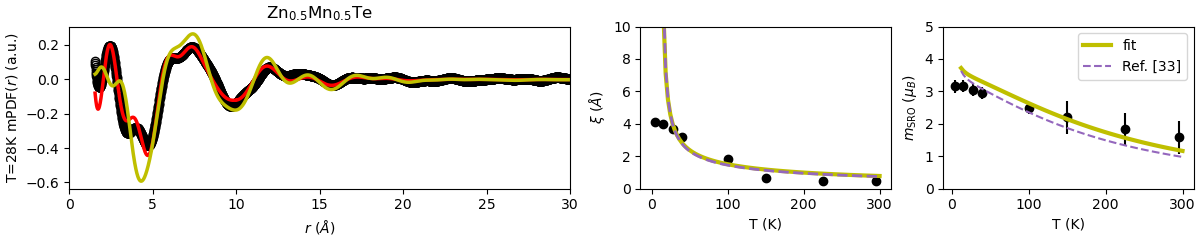

In [25]:
from matplotlib.gridspec import GridSpec

labelsize = 10
ticksize = 10

fig = plt.figure(layout = "constrained", figsize = (12, 2.4))
gs = GridSpec(1, 4, figure = fig)
axmPDF = fig.add_subplot(gs[0, 0:2])
ax1 = fig.add_subplot(gs[0, 2])
ax2 = fig.add_subplot(gs[0, 3])

axmPDF.plot(rdat[150:], mpdfobs[150:], 'bo', label = "mPDF(r) data", markerfacecolor='none',
            markeredgecolor='black')
axmPDF.plot(rdat[150:], mpdfcalc[150:], 'r-', lw=2.5, label = "mPDF(r) atomistic fit")
axmPDF.plot(rcalc[155:], dcalc[155:], 'y-', lw=2.5, label = "mPDF(r) from exchange fits")
axmPDF.set_title(r'Zn$_{0.5}$Mn$_{0.5}$Te')
axmPDF.set_xlim(0.5, 20)
axmPDF.set_xlim(0, 30)
axmPDF.set_xlabel(r'$r$ ($\AA$)', fontsize = labelsize)
axmPDF.set_ylabel(r'T=28K mPDF$(r)$ (a.u.)', fontsize = labelsize)

ax1.scatter(data_temps, xi_data, c = 'black', label = r'data')
ax1.errorbar(data_temps,xi_data, yerr = xi_err, fmt = 'none', c = 'black')
ax1.plot(temps,xis_fit_avg_geo, '-', lw = 3, c = 'y', label = 'fit', alpha = 1)
ax1.plot(temps,xis_87_avg_geo, '--', lw = 2.0, c = 'tab:purple')
ax1.set_ylim(0, 10)
ax1.set_xlabel('T (K)', fontsize = labelsize)
ax1.set_ylabel(r'$\xi$ ($\AA$)',fontsize = labelsize)
ax1.tick_params(axis = 'x', labelsize = ticksize)
ax1.tick_params(axis = 'y', labelsize = ticksize)

tidx_fit = 4
tidx_87 = 4
ax2.scatter(data_temps, lmop_data, c = 'black')
ax2.errorbar(data_temps, lmop_data, yerr = lmop_err, fmt = 'none', c = 'black')
ax2.plot(temps[tidx_fit:], magint_fit.lmops[tidx_fit:], c = 'y', lw = 3, label = 'fit', alpha = 1)
ax2.plot(temps[tidx_87:], magint_87.lmops[tidx_87:], '--', c = 'tab:purple', label = 'Ref. [33]')
ax2.set_ylim(0, 5)
ax2.set_xlabel('T (K)',fontsize = labelsize)
ax2.set_ylabel(r'$m_{\mathrm{SRO}}$ ($\mu_B$)', fontsize = labelsize)
ax2.legend()
ax2.tick_params(axis = 'x', labelsize = ticksize)
ax2.tick_params(axis = 'y', labelsize = ticksize)

plt.savefig('figures/ZnMnTeFits.png',dpi=1200)
plt.show()

# Which temperatures are most important?

In [26]:
### Optimal Experiment Design
from __future__ import annotations
from scipy.optimize._numdiff import approx_derivative
from numpy.typing import NDArray

import warnings
import numpy as np
import cvxpy as cp

def jacobian(
    theta: NDArray[np.float64],
    x: NDArray[np.float64],
    model_fn,
) -> NDArray[np.float64]:
    """
    Numerical Jacobian via central differences with adaptive step size.

    Parameters
    ----------
    theta : ndarray, shape (M,)
        Parameters — differentiation variable.
    x : ndarray, shape (N,)
        Fixed inputs, passed through to model_fn via closure/args.
    model_fn : Callable[[ndarray], ndarray]
        Must take theta ONLY and return y of shape (N,); wrap with a lambda
        to freeze x.

    Returns
    -------
    J : ndarray, shape (N, M)
    """
    return approx_derivative(
        model_fn, theta, method="3-point", rel_step=None  # None -> auto-selects optimal h
    )

def minimize_l1_norm_psd_constraint(
    A_stack: np.ndarray,
    B: np.ndarray,
    strict_margin: float = 0.0,
    solver: str = 'SCS',
    eps: float = 1e-6,
    max_iters: int = 100000,
) -> tuple[np.ndarray, float, str]:
    """Minimize sum(x) subject to x_i > 0 and (sum_i x_i * A_i - B) is PSD.

    Parameters
    ----------
    A_stack : np.ndarray, shape (m, n, n)
        Stack of m constraint matrices, A_stack[i] = A_i. Each A_i need
        NOT be symmetric a priori, but see note in Critical Analysis --
        only the symmetric part of the combination is physically
        meaningful for a PSD constraint, and asymmetric A_i most likely
        indicates a modeling bug.
    B : np.ndarray, shape (n, n)
        Target matrix; constraint is (sum_i x_i * A_i - B) >> 0.
    strict_margin : float, default 1e-9
        Proxy for strict positivity x_i > 0.
    solver : str, default cp.CLARABEL
        SDP-capable CVXPY solver. Alternatives: cp.SCS (older, more
        widely available in older CVXPY installs), cp.MOSEK (commercial,
        much faster/more robust for larger n, requires a license).

    Returns
    -------
    x_opt : np.ndarray, shape (m,)
        Optimal weights.
    optimal_value : float
        Minimal value of sum(x) (== ||x||_1 since x > 0).
    status : str
        CVXPY problem status string (e.g. "optimal", "infeasible").

    Raises
    ------
    ValueError
        If shapes are inconsistent, or if A_i / B are not square.
    RuntimeError
        If the solver does not report an optimal solution.
    """
    A_stack = np.asarray(A_stack, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)

    if A_stack.ndim != 3 or A_stack.shape[1] != A_stack.shape[2]:
        raise ValueError(f"A_stack must have shape (m, n, n); got {A_stack.shape}.")
    m, n, _ = A_stack.shape
    if B.shape != (n, n):
        raise ValueError(f"B must have shape ({n}, {n}); got {B.shape}.")

    # PSD constraints are only meaningful for symmetric matrices (eigenvalues
    # of a non-symmetric real matrix can be complex, so "PSD" is undefined).
    # If your A_i, B aren't already symmetric, this symmetrizes them via
    # (M + M.T)/2, which is the standard convention -- see Critical Analysis.
    B_sym = 0.5 * (B + B.T)
    A_stack_sym = 0.5 * (A_stack + A_stack.transpose(0, 2, 1))

    x = cp.Variable(m, pos=True)  # pos=True enforces x_i > 0 approx. (see notes)

    # Build the weighted sum sum_i x_i * A_i as a CVXPY expression.
    # cp.sum with a list comprehension is the standard idiom for this;
    # there is no vectorized "einsum" equivalent in CVXPY's expression
    # graph API, since each term must remain a traceable affine atom.
    weighted_sum = cp.sum([x[i] * A_stack_sym[i] for i in range(m)])

    constraints = [
        x >= strict_margin,           # numerical proxy for x_i > 0
        weighted_sum - B_sym >> 0,    # the LMI / PSD constraint
    ]

    objective = cp.Minimize(cp.sum(x))  # == ||x||_1 since x > 0
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=solver, eps=eps, max_iters=max_iters)

    if problem.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"SDP did not solve to optimality: status={problem.status}")
        
    if problem.status == "optimal_inaccurate":
        warnings.warn(f"Iteration solve was inaccurate (status={problem.status}); "
                       "consider tightening SCS tolerance or checking convergence stability.")
    elif problem.status != "optimal":
        raise RuntimeError(f"SDP failed: status={problem.status}")

    print(f"Number of iterations: {problem.solver_stats.num_iters}")

    return x.value, problem.value, problem.status

# Initialize

x = data_temps_high
theta_0 = j_ij_fit
sigma = np.diag(0.1 * theta_0) ** 2
w_opt = np.zeros_like(x)
max_iter = 20
tol = 0.05

fim_fm_array = np.zeros((len(x), len(theta_0), len(theta_0)))

for i in range(max_iter):
    fim_g = np.linalg.inv(sigma)
    
    for j in range(len(x)):
        x_m = np.array([x[j]])
        j_fm = jacobian(theta_0, x_m, lambda th: model(x_m, th))
        fim_fm = j_fm.T @ j_fm
        
        fim_fm_array[j] = fim_fm
    
    w, opt_val, status = minimize_l1_norm_psd_constraint(fim_fm_array, fim_g, eps=1e-10,
                                                             max_iters=10000000)
    print(f"Status: {status}")
    print(f"Minimal 1-norm: {opt_val:.6f}")

    # Verify: eigenvalues of (sum_m w_m fim_fm - fim_g) should all be >= 0
    reconstructed = np.einsum("i,ijk->jk", w, fim_fm_array)
    eigvals = np.linalg.eigvalsh(reconstructed - fim_g)
    print(f"Min eigenvalue of (A - B) (should be >= -tol): {eigvals.min():.6e}")
    
    w_old = w_opt.copy()
    w_opt = np.maximum(w, w_opt)
    delta_w = np.sum(np.abs(w_opt - w_old))
    
    print(f"\nFor theta_0 = {theta_0}")
    print(f"Optimal w: {w_opt}")
    print(f"delta w = {delta_w}\n")
        
    if delta_w < tol:
        break
    
    def residuals(theta):
        f = model(x, theta)
        y = np.concatenate([xi_high_data, lmop_high_data])

        res = y - f
        weights = np.sqrt(np.concatenate([w_opt, w_opt]))

        return weights * res
    
    result = least_squares(residuals, theta_0, method = 'lm')
    theta_0 = result.x
    
print(f'Necessary temperatures: {data_temps_high[np.where(w_opt > 1e-8)]}')

Number of iterations: 675
Status: optimal
Minimal 1-norm: 634.869787
Min eigenvalue of (A - B) (should be >= -tol): -2.441780e-11

For theta_0 = [-10.4821606   -1.03938799]
Optimal w: [2.48406564e+02 5.75302813e-12 3.86463223e+02 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
delta w = 634.8697866934211

Number of iterations: 400
Status: optimal
Minimal 1-norm: 1258.381927
Min eigenvalue of (A - B) (should be >= -tol): 6.702052e-10

For theta_0 = [-9.47336429 -1.32907408]
Optimal w: [5.60555458e+02 5.75302813e-12 6.97826469e+02 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
delta w = 623.5121403107262

Number of iterations: 625
Status: optimal
Minimal 1-norm: 1590.450120
Min eigenvalue of (A - B) (should be >= -tol): 8.868579e-09

For theta_0 = [-9.38045775 -1.45282499]
Optimal w: [6.92960538e+02 5.75302813e-12 8.97489581e+02 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
delta w = 332.0681925545613

Number of iterations: 350
Status: optimal
Minimal 1-norm: 1604.717624
Min eigenvalue o

In [27]:
def residuals_necessary_temps(theta):
    idxs_to_keep = np.where(w_opt >= 1e-9)
    x = data_temps_high[idxs_to_keep]
    f = model(x, theta)
    y = np.concatenate([xi_high_data[idxs_to_keep], lmop_high_data[idxs_to_keep]])
    
    res = y - f
    weights = 1 / np.concatenate([xi_high_err[idxs_to_keep], lmop_high_err[idxs_to_keep]])
    
    return np.asarray(weights * res, dtype=float).flatten()

theta = np.array(j_ij_fit, dtype=float)
bounds = ([-np.inf, -np.inf], [0, 0])
result = least_squares(residuals_necessary_temps, theta, method="dogbox", bounds=bounds, diff_step=1e-9)

print(result.x)

[-10.15493262  -1.07667314]


<IPython.core.display.Javascript object>


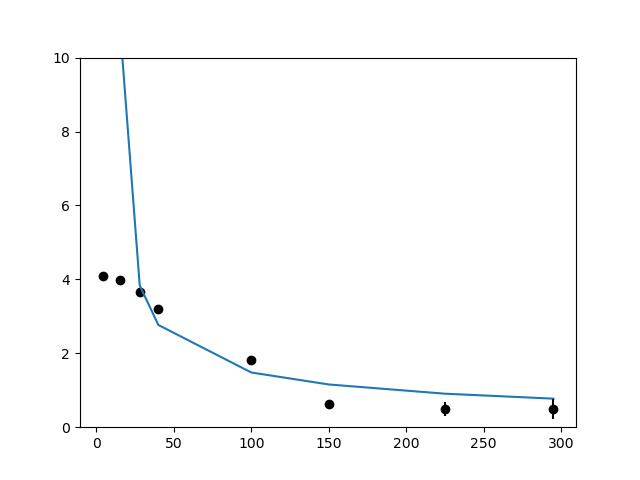

<IPython.core.display.Javascript object>


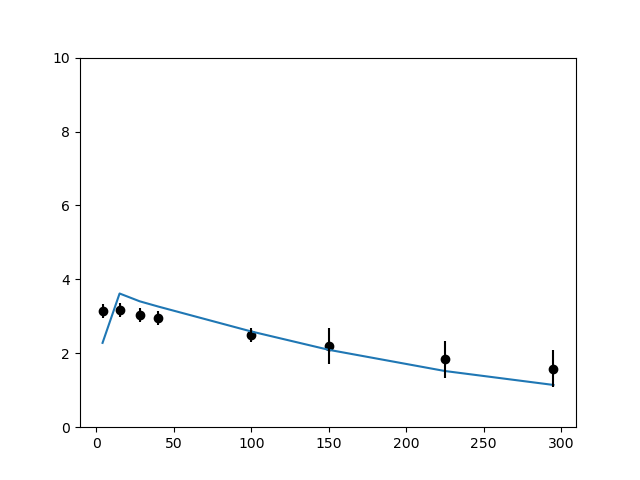

In [28]:
fit_output = model(data_temps, result.x)
xis_fit = fit_output[:len(data_temps)]
lmops_fit = fit_output[len(data_temps):]

plt.figure()
plt.plot(data_temps, xis_fit)
plt.scatter(data_temps, xi_data, c = 'black', label = r'data')
plt.errorbar(data_temps,xi_data, yerr = xi_err, fmt = 'none', c = 'black')
plt.ylim(0,10)
plt.show()

plt.figure()
plt.plot(data_temps, lmops_fit)
plt.scatter(data_temps, lmop_data, c = 'black')
plt.errorbar(data_temps, lmop_data, yerr = lmop_err, fmt = 'none', c = 'black')
plt.ylim(0,10)
plt.show()